In [ ]:
import duckdb
import pandas as pd
import numpy as np  # <--- 修正 1: 直接導入 numpy
import pickle
import os
from sklearn.preprocessing import LabelEncoder

# =========================
# 參數設定
# =========================
DB_PATH = "data/gdelt_daily_bilateral_by_eventcode_add.duckdb"
SRC_TABLE = "daily_bilateral_eventbasecode_sorted" 
OUT_TABLE = "training_ready_data"
MAPPING_FILE = "data/gdelt_mappings.pkl"

def build_optimized_structure():
    # 如果想強制重跑，可以把下面這行註解掉，或是手動刪除 .pkl 檔
    if os.path.exists(MAPPING_FILE):
        print("偵測到映射檔已存在，跳過重建結構。")
        # 若您想確保資料庫欄位正確，建議在此處強行繼續，
        # 只要註解掉上面的 return 即可，或者刪除舊的 pkl 檔案。
        # 為了安全起見，這裡我讓它繼續執行資料庫寫入的部分：
        pass 

    con = duckdb.connect(DB_PATH)
    print("1. 正在檢查/建立 ID 映射...")
    
    # 讀取所有實體與關係
    entities = con.execute(f"SELECT DISTINCT src_country FROM {SRC_TABLE} UNION SELECT DISTINCT dst_country FROM {SRC_TABLE}").df()['src_country'].tolist()
    relations = con.execute(f"SELECT DISTINCT event_code FROM {SRC_TABLE}").df()['event_code'].tolist()
    dates = con.execute(f"SELECT DISTINCT date_added FROM {SRC_TABLE} ORDER BY date_added").df()['date_added'].tolist()
    
    entity_le = LabelEncoder().fit(entities)
    rel_le = LabelEncoder().fit(relations)
    date_map = {date: idx for idx, date in enumerate(dates)}
    
    # 保存映射
    mappings = {
        'entity_le': entity_le,
        'rel_le': rel_le,
        'date_map': date_map,
        'idx_to_date': {v: k for k, v in date_map.items()},
        'num_entities': len(entities),
        'num_relations': len(relations)
    }
    with open(MAPPING_FILE, "wb") as f:
        pickle.dump(mappings, f)
        
    print(f"2. 正在轉換資料並寫入新表 {OUT_TABLE}...")
    df = con.execute(f"SELECT * FROM {SRC_TABLE}").df()
    
    # 執行轉換
    df['src_id'] = entity_le.transform(df['src_country'])
    df['dst_id'] = entity_le.transform(df['dst_country'])
    df['rel_id'] = rel_le.transform(df['event_code'])
    df['time_idx'] = df['date_added'].map(date_map)
    
    # === 修正 2: 使用 np.log1p 而不是 pd.np.log1p ===
    df['log_weight'] = np.log1p(df['event_count']) 
    
    # 寫入 DB
    con.execute(f"DROP TABLE IF EXISTS {OUT_TABLE}")
    
    # 只寫入模型需要的欄位
    # DuckDB 需要註冊 DataFrame 才能作為表來源
    con.register('temp_df_for_insert', df[['time_idx', 'src_id', 'dst_id', 'rel_id', 'log_weight']])
    con.execute(f"CREATE TABLE {OUT_TABLE} AS SELECT * FROM temp_df_for_insert")
    con.unregister('temp_df_for_insert') # 清理記憶體
    
    # 建立索引
    con.execute(f"CREATE INDEX IF NOT EXISTS idx_time ON {OUT_TABLE} (time_idx)")
    # === 新增這行：強制清理並壓縮檔案 ===
    print("正在執行 VACUUM 以釋放空間 (這可能需要一點時間)...")
    con.execute("VACUUM") 
    
    con.close()
    print("✓ 資料結構初始化完成。")
    
    con.close()
    print("✓ 資料結構初始化完成。現在資料庫中已有 'log_weight' 欄位。")

if __name__ == "__main__":
    build_optimized_structure()


import pandas as pd
import numpy as np

# 1. 讀取原始的已實現波動率資料
rv = pd.read_csv("data/rv.csv")
# 將 date 欄位統一轉為 datetime 格式，方便後續對齊與排序
rv['date'] = pd.to_datetime(rv['date'])

# 2. 讀取 GPR 每日資料 (Excel 檔)
# 根據你的附圖，檔案裡有 date, GPRD, GPRD_ACT, GPRD_THREAT 等欄位
df_gpr = pd.read_excel("data/data_gpr_daily_recent.xls")
df_gpr['date'] = pd.to_datetime(df_gpr['date'])

# 3. 將 GPR 資料從「寬表格」轉成「長表格」
# 這會把 GPRD, GPRD_ACT, GPRD_THREAT 變成 symbol 欄位裡的值
gpr_melted = pd.melt(
    df_gpr,
    id_vars=['date'],                                      # 保留日期欄位
    value_vars=['GPRD', 'GPRD_ACT', 'GPRD_THREAT'],        # 要轉換的目標變數
    var_name='symbol',                                     # 新的變數名稱欄位叫 symbol
    value_name='value'                                     # 數值暫時放在 value 欄位
)

# 4. 依照需求重新賦值：將數值放到 close 和 rv 欄位
gpr_melted['close'] = gpr_melted['value']
gpr_melted['rv'] = gpr_melted['value']
gpr_melted = gpr_melted.drop(columns=['value']) # 移除暫存的 value 欄位

# 5. 補齊其他不需要的欄位，並填入 Null (NaN)
# 找出 rv 有但 gpr_melted 沒有的欄位
missing_cols = [col for col in rv.columns if col not in gpr_melted.columns]
for col in missing_cols:
    gpr_melted[col] = np.nan

# 讓欄位順序與原本的 rv 完全一致
gpr_melted = gpr_melted[rv.columns]

# 6. 將兩份資料上下合併 (Append)
combined_df = pd.concat([rv, gpr_melted], ignore_index=True)

# 7. (選擇性) 依照日期和 symbol 重新排序，讓資料看起來更整齊
combined_df = combined_df.sort_values(by=['date', 'symbol']).reset_index(drop=True)

# 8. 輸出成新的 CSV 檔案
# 將 datetime 格式化為原本的字串格式 (YYYY-MM-DD HH:MM:SS.000) 如果需要的話
combined_df['date'] = combined_df['date'].dt.strftime('%Y-%m-%d 00:00:00.000')

combined_df.to_csv("data/rv_with_gpr.csv", index=False)
print("資料合併完成，已儲存為 data/rv_with_gpr.csv")

偵測到映射檔已存在，跳過重建結構。
1. 正在檢查/建立 ID 映射...
2. 正在轉換資料並寫入新表 training_ready_data...
正在執行 VACUUM 以釋放空間 (這可能需要一點時間)...
✓ 資料結構初始化完成。
✓ 資料結構初始化完成。現在資料庫中已有 'log_weight' 欄位。


資料合併完成，已儲存為 data/new_rv_with_gpr.csv


In [ ]:
import duckdb
import pandas as pd

# 設定資料庫路徑
DB_PATH = "data/gdelt_daily_bilateral_by_eventcode_add.duckdb"

def inspect_duckdb_schema():
    print(f"🔌 正在連接資料庫: {DB_PATH}...\n")
    
    try:
        # read_only=True 避免鎖死資料庫
        con = duckdb.connect(DB_PATH, read_only=True)
    except Exception as e:
        print(f"❌ 無法連接資料庫: {e}")
        return

    # 1. 先找出所有資料表名稱
    tables = con.execute("SHOW TABLES").fetchall()
    table_names = [t[0] for t in tables]
    
    if not table_names:
        print("⚠️ 資料庫中沒有任何資料表。")
        con.close()
        return

    print(f"✅ 找到 {len(table_names)} 張資料表：{table_names}\n")
    print("=" * 60)

    # 2. 逐一顯示每張表的欄位結構
    for table in table_names:
        print(f"📋 資料表名稱: [{table}]")
        
        # 使用 DESCRIBE 指令取得欄位資訊
        schema_df = con.execute(f"DESCRIBE {table}").df()
        
        # 顯示欄位名稱、資料型態、是否允許 Null
        # DuckDB 的 DESCRIBE 回傳欄位通常包含: column_name, column_type, null, key, default, extra
        display_cols = ['column_name', 'column_type'] 
        if 'null' in schema_df.columns:
            display_cols.append('null')
            
        print(schema_df[display_cols].to_string(index=False))
        
        # 順便顯示前 3 筆資料讓您對照內容
        print(f"\n   --- 前 3 筆資料範例 ---")
        try:
            preview_df = con.execute(f"SELECT * FROM {table} LIMIT 3").df()
            print(preview_df.to_string(index=False))
        except Exception as e:
            print(f"   (無法讀取預覽: {e})")

        print("\n" + "=" * 60 + "\n")

    con.close()

if __name__ == "__main__":
    inspect_duckdb_schema()

🔌 正在連接資料庫: data/gdelt_daily_bilateral_by_eventcode_add.duckdb...

✅ 找到 3 張資料表：['daily_bilateral_eventbasecode', 'daily_bilateral_eventbasecode_sorted', 'training_ready_data']

📋 資料表名稱: [daily_bilateral_eventbasecode]
  column_name column_type null
   date_added        DATE  YES
  src_country     VARCHAR  YES
  dst_country     VARCHAR  YES
   event_code     VARCHAR  YES
  event_count      BIGINT  YES
 sum_mentions     HUGEINT  YES
  sum_sources     HUGEINT  YES
 sum_articles     HUGEINT  YES
avg_goldstein      DOUBLE  YES
     avg_tone      DOUBLE  YES
min_goldstein      DOUBLE  YES
max_goldstein      DOUBLE  YES
     min_tone      DOUBLE  YES
     max_tone      DOUBLE  YES

   --- 前 3 筆資料範例 ---
date_added src_country dst_country event_code  event_count  sum_mentions  sum_sources  sum_articles  avg_goldstein  avg_tone  min_goldstein  max_goldstein  min_tone  max_tone
2016-03-02         RUS         RUS        090            2          14.0          2.0          14.0           -2.0 -1.468

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# =========================
# 參數設定
# =========================
OIL_CSV = "data/rv_with_gpr.csv"
SYMBOL = "CL_c1"
OUTPUT_DIR = "baseline_results"

ROLLING_WINDOW_SIZE = 1000

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"已建立資料夾: {OUTPUT_DIR}")


# =========================
# 1. 數據準備
# =========================
def prepare_har_data(csv_path, symbol, horizons_map):
    print("正在準備 HAR Baseline 數據 (含 OVX、GPR)...")
    data = pd.read_csv(csv_path)

    df = data[data["symbol"] == symbol].sort_values(by="date", ascending=True).copy()
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)

    # OVX：日頻隱含波動率，保留日/週/月三欄
    ovx_df = data[data["symbol"] == "OVX"].copy()
    if not ovx_df.empty:
        ovx_df["date"] = pd.to_datetime(ovx_df["date"])
        ovx_df = ovx_df.set_index("date")[["rv"]].rename(columns={"rv": "OVX"})
        df = df.join(ovx_df, how="left")
        df["OVX"] = df["OVX"].ffill()
        df["log_OVX_d"] = np.log(df["OVX"] + 1e-10)
        df["log_OVX_w"] = df["log_OVX_d"].rolling(window=5).mean()
        df["log_OVX_m"] = df["log_OVX_d"].rolling(window=22).mean()
    else:
        print("警告: 找不到 symbol='OVX'！")
        df["log_OVX_d"] = 0.0
        df["log_OVX_w"] = 0.0
        df["log_OVX_m"] = 0.0

    # GPR：CSV 已是日頻，直接讀取，只保留 log_GPR 單欄
    gpr_df = data[data["symbol"] == "GPRD"].copy()
    if not gpr_df.empty:
        gpr_df["date"] = pd.to_datetime(gpr_df["date"])
        gpr_df = gpr_df.set_index("date")[["rv"]].rename(columns={"rv": "GPRD"})
        df = df.join(gpr_df, how="left")
        n_missing = df["GPRD"].isna().sum()
        if n_missing > 0:
            print(f"  [GPRD] {n_missing} 筆缺值，以 ffill 補齊交易日空缺。")
        df["GPRD"] = df["GPRD"].ffill()
        df["log_GPRD"] = np.log(df["GPRD"] + 1e-10)
    else:
        print("警告: 找不到 symbol='GPRD'！HAR-OVX-GPR 將受影響。")
        df["log_GPRD"] = 0.0

    # HAR 標準特徵
    df["RV_d"] = df["rv"]
    df["RV_w"] = df["rv"].rolling(window=5).mean()
    df["RV_m"] = df["rv"].rolling(window=22).mean()
    df["log_RV_d"] = np.log(df["RV_d"] + 1e-10)
    df["log_RV_w"] = np.log(df["RV_w"] + 1e-10)
    df["log_RV_m"] = np.log(df["RV_m"] + 1e-10)

    # HAR-J
    df["Jump"] = np.maximum(df["RV_d"] - df["RV_w"], 0)
    df["log_Jump"] = np.log(df["Jump"] + 1e-10)

    # Targets
    next_day_rv = df["rv"].shift(-1)
    for name, days in horizons_map.items():
        indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=days)
        df[name] = next_day_rv.rolling(window=indexer).mean()

    # 【修改重點 1】：只針對「訓練特徵」進行 dropna，保留最後幾天 Target 為 NaN 的資料
    features_to_check = [
        "log_RV_d", "log_RV_w", "log_RV_m",
        "log_OVX_d", "log_OVX_w", "log_OVX_m",
        "log_GPRD", "log_Jump"
    ]
    df.dropna(subset=features_to_check, inplace=True)

    print(f"  資料範圍: {df.index.min().date()} → {df.index.max().date()}  (N={len(df)})")
    return df


# =========================
# 2. 評估指標
# =========================
def qlike_loss_np(y_true, y_pred):
    eps = 1e-6
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.clip(y_true, eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)


def calculate_r2_oos(y_true, y_pred, y_bench):
    mse_model = np.mean((y_true - y_pred) ** 2)
    mse_bench = np.mean((y_true - y_bench) ** 2)
    return 1 - (mse_model / (mse_bench + 1e-10))


# =========================
# 3. 滾動預測
# =========================
def run_online_har_forecast_full_history(df, target_col, horizon_days,
                                         model_type="HAR", warmup_steps=252):
    base_cols = ["log_RV_d", "log_RV_w", "log_RV_m"]
    ovx_cols = ["log_OVX_d"]#, "log_OVX_w", "log_OVX_m"

    if model_type == "HAR-J":
        feature_cols = base_cols + ["log_Jump"]
    elif model_type == "HAR-OVX":
        feature_cols = base_cols + ovx_cols
    elif model_type == "HAR-OVX-GPR":
        feature_cols = base_cols + ovx_cols + ["log_GPRD"]
    else:
        feature_cols = base_cols

    missing_cols = [c for c in feature_cols if c not in df.columns]
    if missing_cols:
        print(f"錯誤: {model_type} 缺少欄位 {missing_cols}，跳過。")
        return None, None

    scaler = StandardScaler()
    y_true_list, y_pred_list, y_bench_list, dates_list = [], [], [], []

    print(f"\n開始執行 {model_type} Online Training: {target_col}")
    start_index = max(warmup_steps + horizon_days, warmup_steps)
    progress_bar = tqdm(range(start_index, len(df)), desc=f"{model_type}-{target_col}")

    for i in progress_bar:
        row = df.iloc[i:i+1]

        valid_train_end = i - horizon_days
        train_start_idx = max(0, valid_train_end - ROLLING_WINDOW_SIZE)

        if (valid_train_end - train_start_idx) < warmup_steps:
            continue

        train_data = df.iloc[train_start_idx:valid_train_end].copy()
        
        # 【修改重點 2】：訓練模型時，必須排除掉 Target 還是 NaN 的資料
        train_data.dropna(subset=[target_col], inplace=True)
        
        if len(train_data) < warmup_steps:
            continue

        x_test_raw = row[feature_cols].values.reshape(1, -1)
        bench_val = train_data[target_col].mean()

        X_train_raw = train_data[feature_cols].values
        scaler.fit(X_train_raw)
        X_train = scaler.transform(X_train_raw)
        y_train_log = np.log(train_data[target_col].values + 1e-10)

        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train_log)

        x_test = scaler.transform(x_test_raw)
        pred_val = np.exp(model.predict(x_test)[0])

        # 即使 target_col 是 NaN，我們照樣把 pred_val 存下來
        y_true_list.append(row[target_col].iloc[0])
        y_pred_list.append(pred_val)
        y_bench_list.append(bench_val)
        dates_list.append(df.index[i])

    res_df = pd.DataFrame({
        "date": dates_list,
        "Actual": y_true_list,
        "Pred": y_pred_list,
        "Bench": y_bench_list
    })

    if len(res_df) == 0:
        return None, res_df

    # 【修改重點 3】：為了計算評估指標，必須先排除 Actual 為 NaN 的資料
    valid_eval_df = res_df.dropna(subset=["Actual"])

    if len(valid_eval_df) < 2:
        return None, res_df

    y_true_eval = valid_eval_df["Actual"].values
    y_pred_eval = valid_eval_df["Pred"].values
    y_bench_eval = valid_eval_df["Bench"].values

    result_dict = {
        "Horizon": target_col,
        "Model": model_type,
        "R2_Standard": r2_score(y_true_eval, y_pred_eval),
        "R2_OOS": calculate_r2_oos(y_true_eval, y_pred_eval, y_bench_eval),
        "QLIKE": qlike_loss_np(y_true_eval, y_pred_eval),
        "MSE": mean_squared_error(y_true_eval, y_pred_eval),
        "Test_Size": len(y_true_eval),
        "Start_Date": str(valid_eval_df['date'].iloc[0].date()),
        "End_Date": str(valid_eval_df['date'].iloc[-1].date())
    }

    return result_dict, res_df


# =========================
# 4. 主執行邏輯
# =========================
if __name__ == "__main__":

    horizons_map = {
        "Target_1D": 1,
        "Target_1W": 5,
        "Target_2W": 10,
        "Target_3W": 15,
        "Target_1M": 22,
        "Target_2M": 44,
        "Target_3M": 66,
    }

    WARMUP_STEPS = 252
    df = prepare_har_data(OIL_CSV, SYMBOL, horizons_map)

    models = ["HAR", "HAR-J", "HAR-OVX", "HAR-OVX-GPR"]
    all_results = []

    print("\n" + "=" * 60)
    print(f"開始執行 HAR Baseline (輸出至: {OUTPUT_DIR})")
    print("   Window Type : Fixed Rolling (1000)")
    print("   OVX 特徵    : log_OVX_d / log_OVX_w / log_OVX_m")
    print("   GPR 特徵    : log_GPR 單欄（日頻原始值）")
    print("=" * 60)

    for target_name in horizons_map.keys():
        print(f"\n--- {target_name} ---")
        horizon_days = horizons_map[target_name]

        for model_type in models:
            res_dict, res_df = run_online_har_forecast_full_history(
                df, target_name, horizon_days, model_type, warmup_steps=WARMUP_STEPS
            )
            if res_dict is None:
                continue

            all_results.append(res_dict)
            print(f"{model_type} - {target_name}:")
            print(f"  R2_OOS : {res_dict['R2_OOS']:.6f}")
            print(f"  QLIKE  : {res_dict['QLIKE']:.6f}")

            pred_filename = os.path.join(
                OUTPUT_DIR, f"full_history_pred_{model_type}_{target_name}.csv"
            )
            res_df.to_csv(pred_filename, index=False)

    baseline_df = pd.DataFrame(all_results)

    print("\n" + "=" * 60)
    print("HAR Baseline 摘要（Full History）")
    print("=" * 60)
    pd.options.display.float_format = "{:,.6f}".format
    if not baseline_df.empty:
        cols_to_show = ["Horizon", "Model", "R2_OOS", "QLIKE",
                        "Test_Size", "Start_Date", "End_Date"]
        print(baseline_df[cols_to_show])

    summary_filename = os.path.join(OUTPUT_DIR, "har_baseline_full_history_summary.csv")
    baseline_df.to_csv(summary_filename, index=False)
    print(f"\n✓ HAR Baseline (Full History) 執行完成！結果已儲存至 {OUTPUT_DIR}/")

正在準備 HAR Baseline 數據 (含 OVX、GPR)...
  [GPRD] 2 筆缺值，以 ffill 補齊交易日空缺。
  資料範圍: 2010-07-07 → 2026-04-29  (N=3980)

開始執行 HAR Baseline (輸出至: baseline_results)
   Window Type : Fixed Rolling (1000)
   OVX 特徵    : log_OVX_d / log_OVX_w / log_OVX_m
   GPR 特徵    : log_GPR 單欄（日頻原始值）

--- Target_1D ---

開始執行 HAR Online Training: Target_1D


HAR-Target_1D: 100%|██████████| 3727/3727 [00:04<00:00, 794.69it/s]


HAR - Target_1D:
  R2_OOS : 0.168216
  QLIKE  : 0.120680

開始執行 HAR-J Online Training: Target_1D


HAR-J-Target_1D: 100%|██████████| 3727/3727 [00:04<00:00, 796.67it/s]


HAR-J - Target_1D:
  R2_OOS : 0.169419
  QLIKE  : 0.119898

開始執行 HAR-OVX Online Training: Target_1D


...

HAR-J - Target_3M:
  R2_OOS : 0.123686
  QLIKE  : 0.536802

開始執行 HAR-OVX Online Training: Target_3M


HAR-OVX-Target_3M: 100%|██████████| 3662/3662 [00:04<00:00, 831.47it/s]


HAR-OVX - Target_3M:
  R2_OOS : 0.172273
  QLIKE  : 0.483326

開始執行 HAR-OVX-GPR Online Training: Target_3M


HAR-OVX-GPR-Target_3M: 100%|██████████| 3662/3662 [00:04<00:00, 820.61it/s]


HAR-OVX-GPR - Target_3M:
  R2_OOS : 0.174566
  QLIKE  : 0.483091

HAR Baseline 摘要（Full History）
      Horizon        Model   R2_OOS    QLIKE  Test_Size  Start_Date  \
0   Target_1D          HAR 0.168216 0.120680       3726  2011-07-07   
1   Target_1D        HAR-J 0.169419 0.119898       3726  2011-07-07   
2   Target_1D      HAR-OVX 0.216387 0.099422       3726  2011-07-07   
3   Target_1D  HAR-OVX-GPR 0.221697 0.099408       3726  2011-07-07   
4   Target_1W          HAR 0.158587 0.121740       3718  2011-07-13   
5   Target_1W        HAR-J 0.149110 0.121937       3718  2011-07-13   
6   Target_1W      HAR-OVX 0.239415 0.102970       3718  2011-07-13   
7   Target_1W  HAR-OVX-GPR 0.242373 0.103459       3718  2011-07-13   
8   Target_2W          HAR 0.120062 0.150316       3708  2011-07-20   
9   Target_2W        HAR-J 0.111865 0.150562       3708  2011-07-20   
10  Target_2W      HAR-OVX 0.256512 0.123241       3708  2011-07-20   
11  Target_2W  HAR-OVX-GPR 0.258720 0.123596       3

In [5]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# =========================
# 參數設定
# =========================
OIL_CSV             = "data/new_rv_with_gpr.csv"
SYMBOL              = "CL_c1"
OUTPUT_DIR          = "ml_results"
ROLLING_WINDOW_SIZE = 1000
WARMUP_STEPS        = 252
EVAL_START          = "2018-01-01"
EVAL_END            = "2025-12-31"

os.makedirs(OUTPUT_DIR, exist_ok=True)

horizons_map = {
    "Target_1D": 1,
    "Target_1W": 5,
    "Target_2W": 10,
    "Target_1M": 22,
    "Target_2M": 44,
    "Target_3M": 66,
}

# ABESS 特徵（log 尺度版，對應 baseline 的特徵處理方式）
feature_list = {
    "Target_1D": ["log_RV_w", "log_RV_BZ_c1", "log_RV_d", "log_RV_PA_c1", "log_ovx"],
    "Target_1W": ["log_RV_w", "log_RV_RB_c1", "log_RV_m", "log_RV_PA_c1", "log_RV_d", "log_ovx"],
    "Target_2W": ["log_RV_RB_c1", "log_RV_m", "log_RV_HO_c1", "log_RV_w", "log_RV_GC_c1", "log_ovx"],
    "Target_1M": ["log_RV_RB_c1", "log_RV_HO_c1", "log_RV_d", "log_RV_PA_c1", "log_RV_m", "log_ovx"],
    "Target_2M": ["log_RV_RB_c1", "log_RV_YM_c1", "log_RV_ZF_c1", "log_RV_ZN_c1", "log_RV_NQ_c1", "log_ovx"],
    "Target_3M": ["log_RV_RB_c1", "log_RV_YM_c1", "log_RV_NQ_c1", "log_RV_ZN_c1", "log_RV_ZF_c1", "log_ovx"],
}

OTHER_SYMBOLS = ["BZ_c1", "PA_c1", "RB_c1", "HO_c1", "GC_c1", "YM_c1", "ZF_c1", "ZN_c1", "NQ_c1"]

# =========================
# 1. 資料準備
# =========================
def prepare_data(csv_path, symbol, horizons_map):
    print("正在準備資料...")
    data = pd.read_csv(csv_path)

    df = data[data["symbol"] == symbol].sort_values("date").copy()
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)

    # OVX
    ovx_df = data[data["symbol"] == "OVX"].copy()
    if not ovx_df.empty:
        ovx_df["date"] = pd.to_datetime(ovx_df["date"])
        ovx_df = ovx_df.set_index("date")[["rv"]].rename(columns={"rv": "OVX"})
        df = df.join(ovx_df, how="left")
        df["OVX"] = df["OVX"].ffill()
        df["log_ovx"] = np.log(df["OVX"] + 1e-10)
    else:
        print("警告: 找不到 OVX！log_ovx 設為 0")
        df["log_ovx"] = 0.0

    # 跨商品 RV → 同時保留原始與 log 欄位
    for sym in OTHER_SYMBOLS:
        sym_df = data[data["symbol"] == sym].copy()
        raw_col = f"RV_{sym}"
        log_col = f"log_RV_{sym}"
        if not sym_df.empty:
            sym_df["date"] = pd.to_datetime(sym_df["date"])
            sym_df = sym_df.set_index("date")[["rv"]].rename(columns={"rv": raw_col})
            df = df.join(sym_df, how="left")
            df[raw_col] = df[raw_col].ffill().bfill()
            df[log_col] = np.log(df[raw_col] + 1e-10)
        else:
            print(f"警告: 找不到 symbol='{sym}'")
            df[raw_col] = np.nan
            df[log_col] = np.nan

    # HAR 特徵（原始尺度）
    df["RV_d"] = df["rv"]
    df["RV_w"] = df["rv"].rolling(window=5).mean()
    df["RV_m"] = df["rv"].rolling(window=22).mean()

    # HAR 特徵（log 尺度，對齊 baseline）
    df["log_RV_d"] = np.log(df["RV_d"] + 1e-10)
    df["log_RV_w"] = np.log(df["RV_w"] + 1e-10)
    df["log_RV_m"] = np.log(df["RV_m"] + 1e-10)

    # Targets（原始尺度，預測後 exp 還原對比用）
    next_day_rv = df["rv"].shift(-1)
    for name, days in horizons_map.items():
        indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=days)
        df[name] = next_day_rv.rolling(window=indexer).mean()

    # 只 dropna 訓練特徵欄，保留 target 可能為 NaN 的列
    df.dropna(subset=["log_RV_d", "log_RV_w", "log_RV_m", "log_ovx"], inplace=True)

    print(f"  資料範圍: {df.index.min().date()} → {df.index.max().date()}  (N={len(df)})")
    return df

# =========================
# 2. 評估指標（完全對齊 baseline）
# =========================
def qlike_loss_np(y_true, y_pred):
    eps = 1e-6
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.clip(y_true, eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

def calculate_r2_oos(y_true, y_pred, y_bench):
    mse_model = np.mean((y_true - y_pred) ** 2)
    mse_bench = np.mean((y_true - y_bench) ** 2)
    return 1 - (mse_model / (mse_bench + 1e-10))

# =========================
# 3. 滾動預測
# =========================
def run_rolling_ml(df, target_col, feature_names, model_type, horizon_days):

    scaler = StandardScaler()
    y_true_list, y_pred_list, y_bench_list, dates_list = [], [], [], []

    start_index = max(WARMUP_STEPS + horizon_days, WARMUP_STEPS)
    print(f"\n開始執行 {model_type} Online Training: {target_col}")

    for i in tqdm(range(start_index, len(df)), desc=f"{model_type}-{target_col}"):
        row = df.iloc[i:i+1]

        valid_train_end = i - horizon_days
        train_start_idx = max(0, valid_train_end - ROLLING_WINDOW_SIZE)

        if (valid_train_end - train_start_idx) < WARMUP_STEPS:
            continue

        train_data = df.iloc[train_start_idx:valid_train_end].copy()
        train_data.dropna(subset=[target_col], inplace=True)

        if len(train_data) < WARMUP_STEPS:
            continue

        missing = [f for f in feature_names if f not in df.columns]
        if missing or row[feature_names].isnull().values.any():
            continue

        x_test_raw = row[feature_names].values.reshape(1, -1)
        bench_val  = train_data[target_col].mean()   # 原始尺度均值，對齊 baseline

        X_train_raw = train_data[feature_names].values

        # ── 關鍵修正：target 轉 log 尺度訓練，預測後 exp 還原 ──
        y_train_log = np.log(train_data[target_col].values + 1e-10)

        scaler.fit(X_train_raw)
        X_train = scaler.transform(X_train_raw)
        x_test  = scaler.transform(x_test_raw)

        if model_type == "RandomForest_R":
            model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train_log)
            pred_val = np.exp(model.predict(x_test)[0])   # ← exp 還原

        elif model_type == "XGBoost_R":
            model = XGBRegressor(
                n_estimators=100, learning_rate=0.05, max_depth=4,
                subsample=0.8, colsample_bytree=0.8,
                objective="reg:squarederror", verbosity=0, random_state=42
            )
            model.fit(X_train, y_train_log)
            pred_val = np.exp(model.predict(x_test)[0])   # ← exp 還原

        y_true_list.append(row[target_col].iloc[0])
        y_pred_list.append(pred_val)
        y_bench_list.append(bench_val)
        dates_list.append(df.index[i])

    res_df = pd.DataFrame({
        "date":   dates_list,
        "Actual": y_true_list,
        "Pred":   y_pred_list,
        "Bench":  y_bench_list,
    })

    if len(res_df) == 0:
        return None, res_df

    valid_eval_df = res_df.dropna(subset=["Actual"])
    valid_eval_df = valid_eval_df[
        (valid_eval_df["date"] >= EVAL_START) &
        (valid_eval_df["date"] <= EVAL_END)
    ]

    if len(valid_eval_df) < 2:
        return None, res_df

    y_true_eval  = valid_eval_df["Actual"].values
    y_pred_eval  = valid_eval_df["Pred"].values
    y_bench_eval = valid_eval_df["Bench"].values

    result_dict = {
        "Horizon":     target_col,
        "Model":       model_type,
        "R2_Standard": r2_score(y_true_eval, y_pred_eval),
        "R2_OOS":      calculate_r2_oos(y_true_eval, y_pred_eval, y_bench_eval),
        "QLIKE":       qlike_loss_np(y_true_eval, y_pred_eval),
        "MSE":         mean_squared_error(y_true_eval, y_pred_eval),
        "Test_Size":   len(y_true_eval),
        "Start_Date":  str(valid_eval_df["date"].iloc[0].date()),
        "End_Date":    str(valid_eval_df["date"].iloc[-1].date()),
    }
    return result_dict, res_df

# =========================
# 4. 主執行
# =========================
df = prepare_data(OIL_CSV, SYMBOL, horizons_map)

all_results = []
ML_MODELS = ["RandomForest_R", "XGBoost_R"]

print("\n" + "=" * 60)
print(f"開始執行 ML 模型 (輸出至: {OUTPUT_DIR})")
print(f"   Window  : Rolling {ROLLING_WINDOW_SIZE}")
print(f"   評估期間: {EVAL_START} → {EVAL_END}")
print(f"   特徵尺度: log（訓練/預測均在 log 空間，exp 還原）")
print("=" * 60)

for target_name, features in feature_list.items():
    horizon_days = horizons_map[target_name]
    print(f"\n--- {target_name}  特徵: {features} ---")

    for model_type in ML_MODELS:
        res_dict, res_df = run_rolling_ml(df, target_name, features, model_type, horizon_days)
        if res_dict is None:
            continue

        all_results.append(res_dict)
        print(f"{model_type} - {target_name}:")
        print(f"  R2_OOS : {res_dict['R2_OOS']:.6f}")
        print(f"  QLIKE  : {res_dict['QLIKE']:.6f}")

        pred_filename = os.path.join(OUTPUT_DIR, f"full_history_pred_{model_type}_{target_name}.csv")
        res_df.to_csv(pred_filename, index=False)

# =========================
# 5. 摘要輸出
# =========================
summary_df = pd.DataFrame(all_results)

horizon_order = ["Target_1D", "Target_1W", "Target_2W", "Target_1M", "Target_2M", "Target_3M"]
summary_df["Horizon"] = pd.Categorical(summary_df["Horizon"], categories=horizon_order, ordered=True)
summary_df = summary_df.sort_values(["Horizon", "Model"]).reset_index(drop=True)

print("\n" + "=" * 60)
print("ML 模型摘要")
print("=" * 60)
pd.set_option("display.float_format", "{:,.6f}".format)
cols_to_show = ["Horizon", "Model", "R2_OOS", "QLIKE", "Test_Size", "Start_Date", "End_Date"]
display(summary_df[cols_to_show])

summary_path = os.path.join(OUTPUT_DIR, "ml_forecast_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ 完成！摘要已儲存至 {summary_path}")

正在準備資料...
  資料範圍: 2010-07-07 → 2026-04-29  (N=3980)

開始執行 ML 模型 (輸出至: ml_results)
   Window  : Rolling 1000
   評估期間: 2018-01-01 → 2025-12-31
   特徵尺度: log（訓練/預測均在 log 空間，exp 還原）

--- Target_1D  特徵: ['log_RV_w', 'log_RV_BZ_c1', 'log_RV_d', 'log_RV_PA_c1', 'log_ovx'] ---

開始執行 RandomForest_R Online Training: Target_1D


RandomForest_R-Target_1D: 100%|██████████| 3727/3727 [09:10<00:00,  6.77it/s]


RandomForest_R - Target_1D:
  R2_OOS : 0.077205
  QLIKE  : 0.147318

開始執行 XGBoost_R Online Training: Target_1D


XGBoost_R-Target_1D: 100%|██████████| 3727/3727 [04:05<00:00, 15.17it/s]


XGBoost_R - Target_1D:
  R2_OOS : 0.076106
  QLIKE  : 0.155242

--- Target_1W  特徵: ['log_RV_w', 'log_RV_RB_c1', 'log_RV_m', 'log_RV_PA_c1', 'log_RV_d', 'log_ovx'] ---

開始執行 RandomForest_R Online Training: Target_1W


...

RandomForest_R - Target_3M:
  R2_OOS : 0.056166
  QLIKE  : 0.921874

開始執行 XGBoost_R Online Training: Target_3M


XGBoost_R-Target_3M: 100%|██████████| 3662/3662 [3:52:02<00:00,  3.80s/it]    

XGBoost_R - Target_3M:
  R2_OOS : 0.066021
  QLIKE  : 0.905431

ML 模型摘要


,Horizon,Model,R2_OOS,QLIKE,Test_Size,Start_Date,End_Date
0,Target_1D,RandomForest_R,0.077205,0.147318,2012,2018-01-02,2025-12-31
1,Target_1D,XGBoost_R,0.076106,0.155242,2012,2018-01-02,2025-12-31
2,Target_1W,RandomForest_R,0.128976,0.163846,2012,2018-01-02,2025-12-31
3,Target_1W,XGBoost_R,0.166511,0.153655,2012,2018-01-02,2025-12-31
4,Target_2W,RandomForest_R,-0.228599,0.224596,2012,2018-01-02,2025-12-31
5,Target_2W,XGBoost_R,0.015950,0.227886,2012,2018-01-02,2025-12-31
6,Target_1M,RandomForest_R,-0.035792,0.421557,2012,2018-01-02,2025-12-31
7,Target_1M,XGBoost_R,-0.055687,0.485699,2012,2018-01-02,2025-12-31
8,Target_2M,RandomForest_R,0.050160,0.772539,2012,2018-01-02,2025-12-31
9,Target_2M,XGBoost_R,0.061703,0.758853,2012,2018-01-02,2025-12-31



✓ 完成！摘要已儲存至 ml_results/ml_forecast_summary.csv


In [6]:
import os
import numpy as np
import pandas as pd

# =========================
# 參數設定
# =========================
BASELINE_DIR = "baseline_results"   # baseline 的 full_history_pred_*.csv 位置
ML_DIR       = "ml_results"         # ML 模型的 full_history_pred_*.csv 位置
EVAL_START   = "2018-01-01"
EVAL_END     = "2025-12-31"

horizons_map = {
    "Target_1D": 1,
    "Target_1W": 5,
    "Target_2W": 10,
    "Target_1M": 22,
    "Target_2M": 44,
    "Target_3M": 66,
}

# baseline 模型名稱（對應檔名中的 model_type）
BASELINE_MODELS = ["HAR", "HAR-J", "HAR-OVX", "HAR-OVX-GPR"]
# ML 模型名稱
ML_MODELS = ["RandomForest_R", "XGBoost_R"]

# =========================
# QLIKE（與 baseline 完全一致）
# =========================
def qlike_loss_np(y_true, y_pred, eps=1e-6):
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.clip(y_true, eps, None)
    ratio  = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

def calculate_r2_oos(y_true, y_pred, y_bench):
    mse_model = np.mean((y_true - y_pred) ** 2)
    mse_bench = np.mean((y_true - y_bench) ** 2)
    return 1 - (mse_model / (mse_bench + 1e-10))

# =========================
# 讀取 full_history_pred CSV 並計算指標
# =========================
def compute_metrics_from_file(filepath, model_name, target_name, eval_start, eval_end):
    if not os.path.exists(filepath):
        print(f"  [跳過] 找不到檔案: {filepath}")
        return None

    df = pd.read_csv(filepath)
    df["date"] = pd.to_datetime(df["date"])

    # 篩選比較期間
    df = df[(df["date"] >= eval_start) & (df["date"] <= eval_end)]

    # 對齊 baseline 修改重點 3：評估只用 Actual 非 NaN 的列
    df = df.dropna(subset=["Actual"])

    if len(df) < 2:
        print(f"  [跳過] {model_name} {target_name} 期間內有效資料不足")
        return None

    y_true = df["Actual"].values
    y_pred = df["Pred"].values
    y_bench= df["Bench"].values

    return {
        "Horizon":   target_name,
        "Model":     model_name,
        "QLIKE":     qlike_loss_np(y_true, y_pred),
        "R2_OOS":    calculate_r2_oos(y_true, y_pred, y_bench),
        "MSE":       np.mean((y_true - y_pred) ** 2),
        "Test_Size": len(df),
        "Start_Date":str(df["date"].iloc[0].date()),
        "End_Date":  str(df["date"].iloc[-1].date()),
    }

# =========================
# 主執行：讀取所有 CSV 並彙整
# =========================
all_results = []

for target_name in horizons_map.keys():

    # ── Baseline 模型 ──
    for model_name in BASELINE_MODELS:
        fname = os.path.join(BASELINE_DIR, f"full_history_pred_{model_name}_{target_name}.csv")
        res = compute_metrics_from_file(fname, model_name, target_name, EVAL_START, EVAL_END)
        if res:
            all_results.append(res)

    # ── ML 模型 ──
    for model_name in ML_MODELS:
        fname = os.path.join(ML_DIR, f"full_history_pred_{model_name}_{target_name}.csv")
        res = compute_metrics_from_file(fname, model_name, target_name, EVAL_START, EVAL_END)
        if res:
            all_results.append(res)

# =========================
# 整理與顯示
# =========================
summary = pd.DataFrame(all_results)

horizon_order = ["Target_1D", "Target_1W", "Target_2W", "Target_1M", "Target_2M", "Target_3M"]
summary["Horizon"] = pd.Categorical(summary["Horizon"], categories=horizon_order, ordered=True)
summary = summary.sort_values(["Horizon", "Model"]).reset_index(drop=True)

# QLIKE 差值（以 HAR 為基準，負值代表優於 HAR）
qlike_pivot = summary.pivot(index="Horizon", columns="Model", values="QLIKE")
if "HAR" in qlike_pivot.columns:
    for col in qlike_pivot.columns:
        if col != "HAR":
            qlike_pivot[f"{col}_vs_HAR"] = qlike_pivot[col] - qlike_pivot["HAR"]

print("=" * 80)
print(f"QLIKE & R2_OOS 比較  ({EVAL_START} → {EVAL_END})")
print("=" * 80)
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
display(summary[["Horizon","Model","QLIKE","R2_OOS","MSE","Test_Size","Start_Date","End_Date"]])

print("\n── QLIKE 差值矩陣（vs HAR，負值=優於 HAR）──")
display(qlike_pivot.round(6))

# 儲存
out_path = "qlike_comparison_summary.csv"
summary.to_csv(out_path, index=False)
print(f"\n✓ 已儲存至 {out_path}")

QLIKE & R2_OOS 比較  (2018-01-01 → 2025-12-31)


,Horizon,Model,QLIKE,R2_OOS,MSE,Test_Size,Start_Date,End_Date
0,Target_1D,HAR,0.140441,0.166223,0.000056,2012,2018-01-02,2025-12-31
1,Target_1D,HAR-J,0.140425,0.167447,0.000056,2012,2018-01-02,2025-12-31
2,Target_1D,HAR-OVX,0.116372,0.214182,0.000053,2012,2018-01-02,2025-12-31
3,Target_1D,HAR-OVX-GPR,0.115495,0.219643,0.000052,2012,2018-01-02,2025-12-31
4,Target_1D,RandomForest_R,0.147318,0.077205,0.000062,2012,2018-01-02,2025-12-31
5,Target_1D,XGBoost_R,0.155242,0.076106,0.000062,2012,2018-01-02,2025-12-31
6,Target_1W,HAR,0.150797,0.153161,0.000022,2012,2018-01-02,2025-12-31
7,Target_1W,HAR-J,0.150793,0.143576,0.000023,2012,2018-01-02,2025-12-31
8,Target_1W,HAR-OVX,0.136783,0.232679,0.000020,2012,2018-01-02,2025-12-31
9,Target_1W,HAR-OVX-GPR,0.136655,0.235916,0.000020,2012,2018-01-02,2025-12-31



── QLIKE 差值矩陣（vs HAR，負值=優於 HAR）──


Model,HAR,HAR-J,HAR-OVX,HAR-OVX-GPR,RandomForest_R,XGBoost_R,HAR-J_vs_HAR,HAR-OVX_vs_HAR,HAR-OVX-GPR_vs_HAR,RandomForest_R_vs_HAR,XGBoost_R_vs_HAR
Horizon,,,,,,,,,,,
Target_1D,0.140441,0.140425,0.116372,0.115495,0.147318,0.155242,-0.000015,-0.024069,-0.024946,0.006877,0.014802
Target_1W,0.150797,0.150793,0.136783,0.136655,0.163846,0.153655,-0.000004,-0.014015,-0.014142,0.013048,0.002858
Target_2W,0.182774,0.182948,0.163431,0.163591,0.224596,0.227886,0.000175,-0.019342,-0.019182,0.041822,0.045112
Target_1M,0.272650,0.272417,0.223689,0.223066,0.421557,0.485699,-0.000234,-0.048961,-0.049584,0.148907,0.213049
Target_2M,0.560790,0.559843,0.482963,0.479991,0.772539,0.758853,-0.000947,-0.077827,-0.080799,0.211749,0.198063
Target_3M,0.824268,0.822327,0.731189,0.730811,0.921874,0.905431,-0.001941,-0.093079,-0.093457,0.097606,0.081163



✓ 已儲存至 qlike_comparison_summary.csv


In [2]:
import pandas as pd
import numpy as np

# ── 讀取預測結果 ──────────────────────────────────────────
pred_df = pd.read_csv("ml_results/WTI_RV_forecast_results.csv")

# ── QLIKE 計算函數 ────────────────────────────────────────
def qlike(y_true, y_pred, eps=1e-6):
    y_true = np.clip(y_true, eps, None)
    y_pred = np.clip(y_pred, eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

# ── Baseline = 訓練集 Y_true 的滾動歷史均值（expanding mean）
# 用全部 Y_true 的 expanding mean 作為 naive baseline
# 依 Horizon 分組計算
results = []

for (horizon, model), group in pred_df.groupby(["Horizon", "Model"]):
    group = group.sort_values("Index").reset_index(drop=True)
    y_true = group["Y_true"].values
    y_pred = group["Y_pred"].values

    # Baseline：expanding mean of Y_true（每一步只看到當前之前的值）
    baseline_pred = pd.Series(y_true).expanding().mean().shift(1).fillna(method="bfill").values

    qlike_model    = qlike(y_true, y_pred)
    qlike_baseline = qlike(y_true, baseline_pred)
    mse_model      = np.mean((y_true - y_pred) ** 2)
    mse_baseline   = np.mean((y_true - baseline_pred) ** 2)
    r2_oos         = 1 - mse_model / (mse_baseline + 1e-10)

    results.append({
        "Horizon":        horizon,
        "Model":          model,
        "QLIKE_Model":    round(qlike_model, 6),
        "QLIKE_Baseline": round(qlike_baseline, 6),
        "QLIKE_Diff":     round(qlike_model - qlike_baseline, 6),  # 負值表示模型優於 baseline
        "MSE_Model":      round(mse_model, 8),
        "MSE_Baseline":   round(mse_baseline, 8),
        "R2_OOS":         round(r2_oos, 6),
        "N":              len(y_true),
    })

summary = pd.DataFrame(results)

# 依 Horizon 排序（自訂順序）
horizon_order = ["Target_1D", "Target_1W", "Target_2W", "Target_1M", "Target_2M", "Target_3M"]
summary["Horizon"] = pd.Categorical(summary["Horizon"], categories=horizon_order, ordered=True)
summary = summary.sort_values(["Horizon", "Model"]).reset_index(drop=True)

# ── 輸出 ─────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("=" * 90)
print("WTI RV 預測結果：QLIKE vs Baseline 比較")
print("（QLIKE_Diff < 0 表示模型優於 Baseline）")
print("=" * 90)
display(summary)

# 儲存摘要
summary.to_csv("ml_results/qlike_vs_baseline_summary.csv", index=False)
print("\n✓ 已儲存至 ml_results/qlike_vs_baseline_summary.csv")

WTI RV 預測結果：QLIKE vs Baseline 比較
（QLIKE_Diff < 0 表示模型優於 Baseline）


,Horizon,Model,QLIKE_Model,QLIKE_Baseline,QLIKE_Diff,MSE_Model,MSE_Baseline,R2_OOS,N
0,Target_1D,RandomForest_R,0.182744,0.634366,-0.451621,0.000005,0.000003,-0.475794,586
1,Target_1D,XGBoost_R,0.190095,0.634366,-0.444271,0.000005,0.000003,-0.355110,586
2,Target_1W,RandomForest_R,0.174024,0.553661,-0.379638,0.000001,0.000002,0.203630,582
3,Target_1W,XGBoost_R,0.173108,0.553661,-0.380554,0.000001,0.000002,0.318815,582
4,Target_2W,RandomForest_R,0.216853,0.507925,-0.291072,0.000001,0.000001,0.371022,577
5,Target_2W,XGBoost_R,0.245830,0.507925,-0.262095,0.000001,0.000001,0.321451,577
6,Target_1M,RandomForest_R,0.360369,0.434963,-0.074594,0.000001,0.000001,0.061291,565
7,Target_1M,XGBoost_R,0.408180,0.434963,-0.026782,0.000001,0.000001,0.013079,565
8,Target_2M,RandomForest_R,0.401898,0.315957,0.085942,0.000001,0.000000,-0.096915,543
9,Target_2M,XGBoost_R,0.348284,0.315957,0.032327,0.000000,0.000000,-0.042674,543



✓ 已儲存至 ml_results/qlike_vs_baseline_summary.csv


讀取原始資料與預測資料中...
繪圖區間: 2025-10-01 至 2026-04-28
資料筆數: 147
圖表已儲存至: results/forecast_vs_actual_plot.png


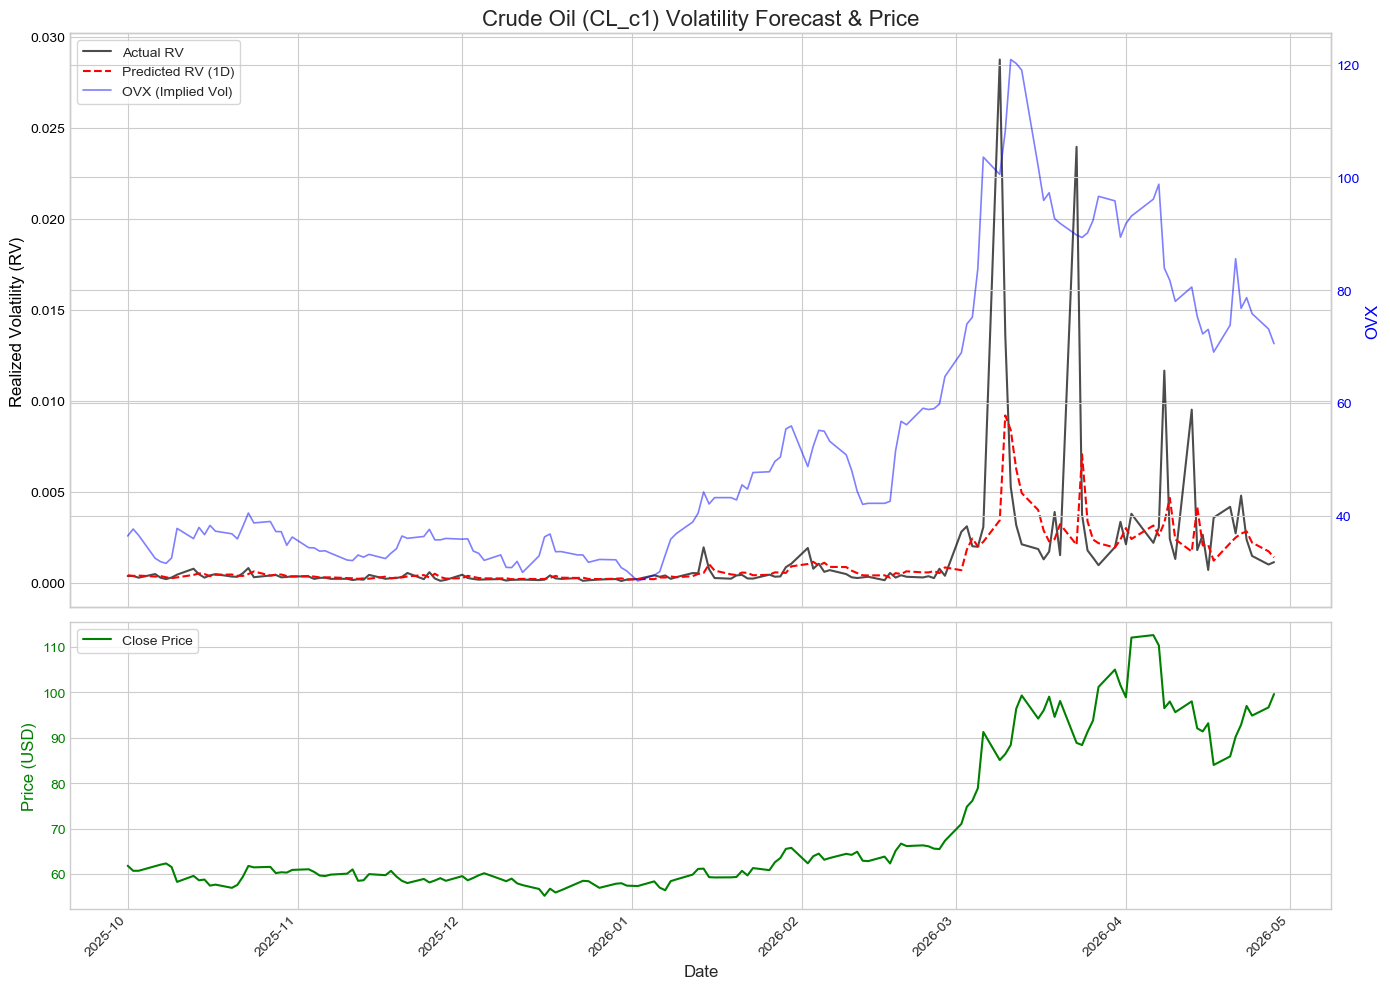

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# =========================
# 1. 參數與檔案路徑設定
# =========================
OIL_CSV = "data/new_rv_with_gpr.csv"

# 請替換成你想畫的「預測結果」檔案路徑 (這邊以 RollPCA 的 1D 預測為例)
PRED_CSV = "results/full_history_pred_HAR-OVX+RollPCA(1)_Target_1D.csv" 

START_DATE = "2025-10-01"
END_DATE = "2026-04-28"
SYMBOL = "CL_c1"
SAVE_FIG_PATH = "results/forecast_vs_actual_plot.png"

# =========================
# 2. 讀取與整理資料
# =========================
print("讀取原始資料與預測資料中...")

# 讀取原始資料 (用來取得 收盤價 與 OVX)
df_raw = pd.read_csv(OIL_CSV)
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 篩選 CL_c1 的真實 RV 與收盤價
df_cl = df_raw[df_raw['symbol'] == SYMBOL][['date', 'close', 'rv']].copy()
df_cl.rename(columns={'rv': 'Actual_RV', 'close': 'Close_Price'}, inplace=True)

# 篩選 OVX 
df_ovx = df_raw[df_raw['symbol'] == 'OVX'][['date', 'rv']].copy()
df_ovx.rename(columns={'rv': 'OVX'}, inplace=True)

# 讀取模型的預測結果 (裡面應包含 date, Actual, Pred 等欄位)
if os.path.exists(PRED_CSV):
    df_pred = pd.read_csv(PRED_CSV)
    df_pred['date'] = pd.to_datetime(df_pred['date'])
    # 只需要日期跟預測值
    df_pred = df_pred[['date', 'Pred']].copy()
else:
    print(f"警告: 找不到預測檔案 {PRED_CSV}！將只畫出真實值。")
    df_pred = pd.DataFrame(columns=['date', 'Pred'])

# 合併所有資料
# 以 df_cl 為基礎，把 OVX 跟 Pred 透過日期合併進來
merged_df = pd.merge(df_cl, df_ovx, on='date', how='left')
merged_df = pd.merge(merged_df, df_pred, on='date', how='left')

# 【新增此行】將 t 日做出的預測值往下平移 1 天，對齊 t+1 的真實 RV (適用於 1D 預測)
merged_df['Pred'] = merged_df['Pred'].shift(1)

# 填補 OVX 可能的空缺 (遇到假日等)
merged_df['OVX'] = merged_df['OVX'].ffill()

# =========================
# 3. 根據指定日期區間截斷資料
# =========================
mask = (merged_df['date'] >= pd.Timestamp(START_DATE)) & (merged_df['date'] <= pd.Timestamp(END_DATE))
plot_df = merged_df.loc[mask].copy()

plot_df.set_index('date', inplace=True)
plot_df.sort_index(inplace=True)

print(f"繪圖區間: {plot_df.index.min().date()} 至 {plot_df.index.max().date()}")
print(f"資料筆數: {len(plot_df)}")

# =========================
# 4. 開始繪圖
# =========================
# 設定中文字型與圖表風格 (若不需要中文標題可移除)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 用戶顯示中文
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 用戶顯示中文
plt.rcParams['axes.unicode_minus'] = False 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# --- 上半部子圖：RV 與 預測 RV (左 Y 軸) vs OVX (右 Y 軸) ---
# 左軸畫 RV
color_actual = 'black'
color_pred = 'red'
ax1.plot(plot_df.index, plot_df['Actual_RV'], color=color_actual, label='Actual RV', linewidth=1.5, alpha=0.7)
if not plot_df['Pred'].isna().all():
    ax1.plot(plot_df.index, plot_df['Pred'], color=color_pred, label='Predicted RV (1D)', linewidth=1.5, linestyle='--')

ax1.set_ylabel('Realized Volatility (RV)', color='black', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Crude Oil (CL_c1) Volatility Forecast & Price', fontsize=16, fontweight='bold')

# 右軸畫 OVX
ax1_twin = ax1.twinx()
color_ovx = 'blue'
ax1_twin.plot(plot_df.index, plot_df['OVX'], color=color_ovx, label='OVX (Implied Vol)', linewidth=1.2, alpha=0.5)
ax1_twin.set_ylabel('OVX', color=color_ovx, fontsize=12, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_ovx)

# 合併上半部的 Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, facecolor='white')

# --- 下半部子圖：CL_c1 收盤價 ---
color_price = 'green'
ax2.plot(plot_df.index, plot_df['Close_Price'], color=color_price, label='Close Price', linewidth=1.5)
ax2.set_ylabel('Price (USD)', color=color_price, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_price)
ax2.legend(loc='upper left', frameon=True, facecolor='white')

# --- X 軸時間格式設定 ---
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.set_xlabel('Date', fontsize=12, fontweight='bold')

# 調整版面與儲存
plt.tight_layout()
plt.savefig(SAVE_FIG_PATH, dpi=300, bbox_inches='tight')
print(f"圖表已儲存至: {SAVE_FIG_PATH}")

plt.show()

讀取原始資料與預測資料 (1M) 中...
繪圖區間: 2025-10-01 至 2026-04-28
資料筆數: 147
圖表已儲存至: results/forecast_vs_actual_plot_1m.png


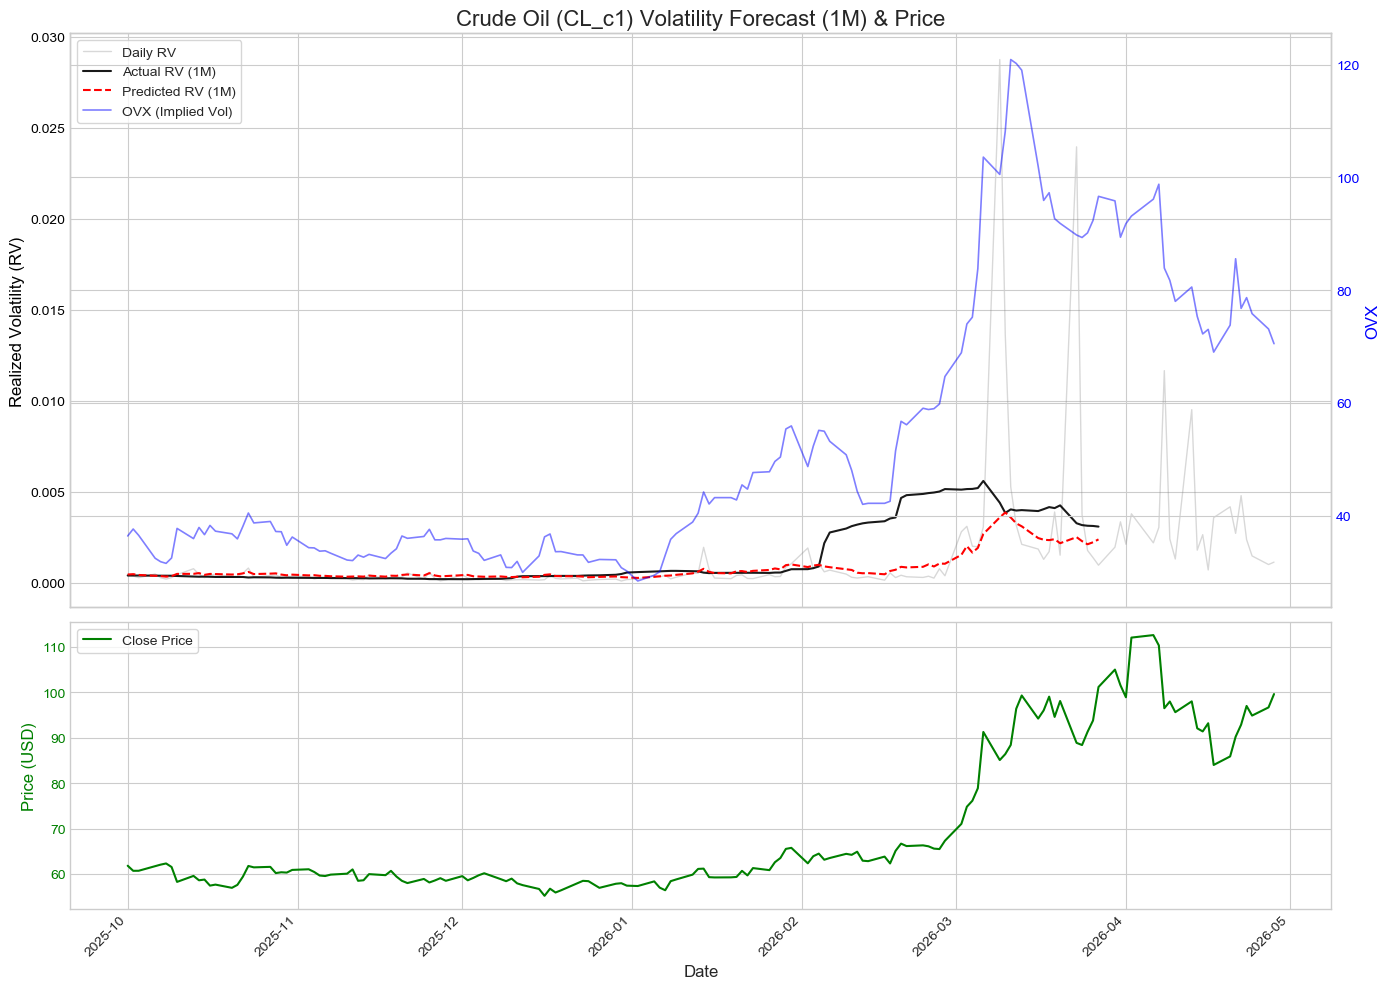

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# =========================
# 1. 參數與檔案路徑設定
# =========================
OIL_CSV = "data/new_rv.csv"

# 設定預測目標區間為 1 個月 (1M)
HORIZON = "1M"

# 動態構建預測結果檔案路徑
PRED_CSV = f"results/full_history_pred_HAR-OVX+RollPCA(1)_Target_{HORIZON}.csv" 

START_DATE = "2025-10-01"
END_DATE = "2026-04-28"
SYMBOL = "CL_c1"

# 依據 HORIZON 動態調整儲存檔名以免覆蓋之前的圖
SAVE_FIG_PATH = f"results/forecast_vs_actual_plot_{HORIZON.lower()}.png"

# =========================
# 2. 讀取與整理資料
# =========================
print(f"讀取原始資料與預測資料 ({HORIZON}) 中...")

# 讀取原始資料 (用來取得 收盤價 與 每日RV 跟 OVX)
df_raw = pd.read_csv(OIL_CSV)
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 篩選 CL_c1 的真實每日 RV 與收盤價
df_cl = df_raw[df_raw['symbol'] == SYMBOL][['date', 'close', 'rv']].copy()
df_cl.rename(columns={'rv': 'Daily_RV', 'close': 'Close_Price'}, inplace=True)

# 篩選 OVX 
df_ovx = df_raw[df_raw['symbol'] == 'OVX'][['date', 'rv']].copy()
df_ovx.rename(columns={'rv': 'OVX'}, inplace=True)

# 讀取模型的預測結果 (裡面應包含 date, Actual, Pred 等欄位)
if os.path.exists(PRED_CSV):
    df_pred = pd.read_csv(PRED_CSV)
    df_pred['date'] = pd.to_datetime(df_pred['date'])
    # 把 Actual 欄位也拿進來，這是對應目標區間(1M)的真實平均值
    df_pred = df_pred[['date', 'Actual', 'Pred']].copy()
    df_pred.rename(columns={'Actual': 'Target_RV'}, inplace=True)
else:
    print(f"警告: 找不到預測檔案 {PRED_CSV}！將只畫出真實值。")
    df_pred = pd.DataFrame(columns=['date', 'Target_RV', 'Pred'])

# 合併所有資料
# 以 df_cl 為基礎，把 OVX 跟 Pred 透過日期合併進來
merged_df = pd.merge(df_cl, df_ovx, on='date', how='left')
merged_df = pd.merge(merged_df, df_pred, on='date', how='left')

# 填補 OVX 可能的空缺 (遇到假日等)
merged_df['OVX'] = merged_df['OVX'].ffill()

# =========================
# 3. 根據指定日期區間截斷資料
# =========================
mask = (merged_df['date'] >= pd.Timestamp(START_DATE)) & (merged_df['date'] <= pd.Timestamp(END_DATE))
plot_df = merged_df.loc[mask].copy()

plot_df.set_index('date', inplace=True)
plot_df.sort_index(inplace=True)

print(f"繪圖區間: {plot_df.index.min().date()} 至 {plot_df.index.max().date()}")
print(f"資料筆數: {len(plot_df)}")

# =========================
# 4. 開始繪圖
# =========================
# 設定中文字型與圖表風格 (若不需要中文標題可移除)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 用戶顯示中文
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 用戶顯示中文
plt.rcParams['axes.unicode_minus'] = False 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# --- 上半部子圖：RV 與 預測 RV (左 Y 軸) vs OVX (右 Y 軸) ---
# 1. 畫出每日 RV 作為背景參考 (淺灰色)
ax1.plot(plot_df.index, plot_df['Daily_RV'], color='gray', label='Daily RV', linewidth=1.0, alpha=0.3)

# 2. 畫出真實的目標 RV (1M 的真實平均，黑色實線)
if 'Target_RV' in plot_df.columns and not plot_df['Target_RV'].isna().all():
    ax1.plot(plot_df.index, plot_df['Target_RV'], color='black', label=f'Actual RV ({HORIZON})', linewidth=1.5, alpha=0.9)

# 3. 畫出預測的 RV (紅色虛線)
if 'Pred' in plot_df.columns and not plot_df['Pred'].isna().all():
    ax1.plot(plot_df.index, plot_df['Pred'], color='red', label=f'Predicted RV ({HORIZON})', linewidth=1.5, linestyle='--')

ax1.set_ylabel('Realized Volatility (RV)', color='black', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title(f'Crude Oil (CL_c1) Volatility Forecast ({HORIZON}) & Price', fontsize=16, fontweight='bold')

# 右軸畫 OVX
ax1_twin = ax1.twinx()
color_ovx = 'blue'
ax1_twin.plot(plot_df.index, plot_df['OVX'], color=color_ovx, label='OVX (Implied Vol)', linewidth=1.2, alpha=0.5)
ax1_twin.set_ylabel('OVX', color=color_ovx, fontsize=12, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_ovx)

# 合併上半部的 Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, facecolor='white')

# --- 下半部子圖：CL_c1 收盤價 ---
color_price = 'green'
ax2.plot(plot_df.index, plot_df['Close_Price'], color=color_price, label='Close Price', linewidth=1.5)
ax2.set_ylabel('Price (USD)', color=color_price, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_price)
ax2.legend(loc='upper left', frameon=True, facecolor='white')

# --- X 軸時間格式設定 ---
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.set_xlabel('Date', fontsize=12, fontweight='bold')

# 調整版面與儲存
plt.tight_layout()
plt.savefig(SAVE_FIG_PATH, dpi=300, bbox_inches='tight')
print(f"圖表已儲存至: {SAVE_FIG_PATH}")

plt.show()

讀取原始資料與預測資料 (1M) 中...
繪圖區間: 2025-10-01 至 2026-04-28
資料筆數: 147
圖表已儲存至: results/forecast_vs_actual_plot_1m.png


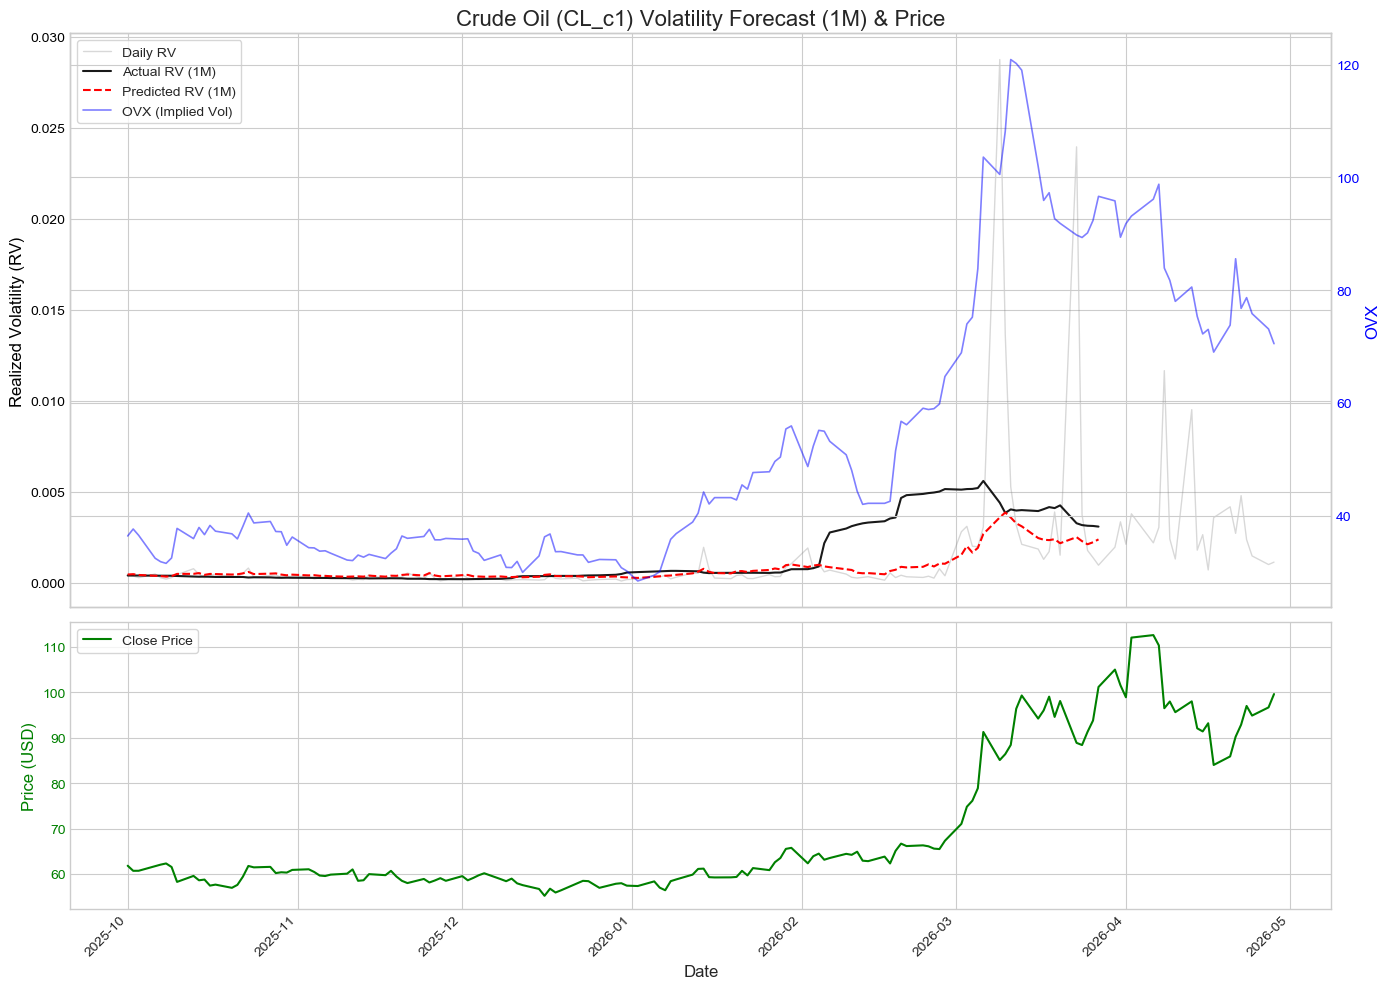

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np

# =========================
# 1. 參數與檔案路徑設定
# =========================
OIL_CSV = "data/new_rv.csv"

# 設定預測目標區間為 1 個月 (1M)
HORIZON = "1M"

# 動態構建預測結果檔案路徑
PRED_CSV = f"results/full_history_pred_HAR-OVX+RollPCA(1)_Target_{HORIZON}.csv" 

START_DATE = "2025-10-01"
END_DATE = "2026-04-28"
SYMBOL = "CL_c1"

# 依據 HORIZON 動態調整儲存檔名以免覆蓋之前的圖
SAVE_FIG_PATH = f"results/forecast_vs_actual_plot_{HORIZON.lower()}.png"

# =========================
# 2. 讀取與整理資料
# =========================
print(f"讀取原始資料與預測資料 ({HORIZON}) 中...")

# 讀取原始資料 (用來取得 收盤價 與 每日RV 跟 OVX)
df_raw = pd.read_csv(OIL_CSV)
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 篩選 CL_c1 的真實每日 RV 與收盤價
df_cl = df_raw[df_raw['symbol'] == SYMBOL][['date', 'close', 'rv']].copy()
df_cl.rename(columns={'rv': 'Daily_RV', 'close': 'Close_Price'}, inplace=True)

# 篩選 OVX 
df_ovx = df_raw[df_raw['symbol'] == 'OVX'][['date', 'rv']].copy()
df_ovx.rename(columns={'rv': 'OVX'}, inplace=True)

# 讀取模型的預測結果 (裡面應包含 date, Actual, Pred 等欄位)
if os.path.exists(PRED_CSV):
    df_pred = pd.read_csv(PRED_CSV)
    df_pred['date'] = pd.to_datetime(df_pred['date'])
    
    # 防呆：確認欄位是否存在，即使 Actual 全部是 NaN 也保留
    cols_to_keep = ['date', 'Pred']
    if 'Actual' in df_pred.columns:
        cols_to_keep.append('Actual')
        
    df_pred = df_pred[cols_to_keep].copy()
    
    if 'Actual' in df_pred.columns:
        df_pred.rename(columns={'Actual': 'Target_RV'}, inplace=True)
    else:
        df_pred['Target_RV'] = np.nan
else:
    print(f"警告: 找不到預測檔案 {PRED_CSV}！將只畫出真實值。")
    df_pred = pd.DataFrame(columns=['date', 'Target_RV', 'Pred'])

# 合併所有資料
# 【修改重點】改成 outer join，確保所有「有預測但沒真實值」的日期都會被保留
merged_df = pd.merge(df_cl, df_ovx, on='date', how='outer')
merged_df = pd.merge(merged_df, df_pred, on='date', how='outer')

# 排列時間並填補可能因為 outer join 產生的空缺 (讓線條不會中斷)
merged_df.sort_values('date', inplace=True)
merged_df['OVX'] = merged_df['OVX'].ffill()
merged_df['Close_Price'] = merged_df['Close_Price'].ffill()

# =========================
# 3. 根據指定日期區間截斷資料
# =========================
mask = (merged_df['date'] >= pd.Timestamp(START_DATE)) & (merged_df['date'] <= pd.Timestamp(END_DATE))
plot_df = merged_df.loc[mask].copy()

plot_df.set_index('date', inplace=True)

print(f"繪圖區間: {plot_df.index.min().date()} 至 {plot_df.index.max().date()}")
print(f"資料筆數: {len(plot_df)}")

# =========================
# 4. 開始繪圖
# =========================
# 設定中文字型與圖表風格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 用戶顯示中文
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 用戶顯示中文
plt.rcParams['axes.unicode_minus'] = False 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# --- 上半部子圖：RV 與 預測 RV (左 Y 軸) vs OVX (右 Y 軸) ---
# 1. 畫出每日 RV 作為背景參考 (淺灰色)
if 'Daily_RV' in plot_df.columns:
    ax1.plot(plot_df.index, plot_df['Daily_RV'], color='gray', label='Daily RV', linewidth=1.0, alpha=0.3)

# 2. 畫出真實的目標 RV (1M 的真實平均，黑色實線)
if 'Target_RV' in plot_df.columns and plot_df['Target_RV'].notna().any():
    ax1.plot(plot_df.index, plot_df['Target_RV'], color='black', label=f'Actual RV ({HORIZON})', linewidth=1.5, alpha=0.9)

# 3. 畫出預測的 RV (紅色虛線) - 就算 Target_RV 是 NaN，這裡有數字就會畫出來
if 'Pred' in plot_df.columns and plot_df['Pred'].notna().any():
    ax1.plot(plot_df.index, plot_df['Pred'], color='red', label=f'Predicted RV ({HORIZON})', linewidth=1.5, linestyle='--')

ax1.set_ylabel('Realized Volatility (RV)', color='black', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title(f'Crude Oil (CL_c1) Volatility Forecast ({HORIZON}) & Price', fontsize=16, fontweight='bold')

# 右軸畫 OVX
if 'OVX' in plot_df.columns:
    ax1_twin = ax1.twinx()
    color_ovx = 'blue'
    ax1_twin.plot(plot_df.index, plot_df['OVX'], color=color_ovx, label='OVX (Implied Vol)', linewidth=1.2, alpha=0.5)
    ax1_twin.set_ylabel('OVX', color=color_ovx, fontsize=12, fontweight='bold')
    ax1_twin.tick_params(axis='y', labelcolor=color_ovx)

    # 合併上半部的 Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, facecolor='white')
else:
    ax1.legend(loc='upper left', frameon=True, facecolor='white')

# --- 下半部子圖：CL_c1 收盤價 ---
color_price = 'green'
if 'Close_Price' in plot_df.columns:
    ax2.plot(plot_df.index, plot_df['Close_Price'], color=color_price, label='Close Price', linewidth=1.5)
    ax2.set_ylabel('Price (USD)', color=color_price, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_price)
    ax2.legend(loc='upper left', frameon=True, facecolor='white')

# --- X 軸時間格式設定 ---
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.set_xlabel('Date', fontsize=12, fontweight='bold')

# 調整版面與儲存
plt.tight_layout()
plt.savefig(SAVE_FIG_PATH, dpi=300, bbox_inches='tight')
print(f"圖表已儲存至: {SAVE_FIG_PATH}")

plt.show()

讀取 GNN Embedding 資料中: gnn_oil_context_OOS_2018.csv
找到 32 個 GNN 特徵欄位，準備進行 PCA 降維...
PC1 計算完成！PC1 總共解釋了 GNN 特徵 30.94% 的變異。
圖表已儲存至: results/gnn_embedding_pc1_plot.png


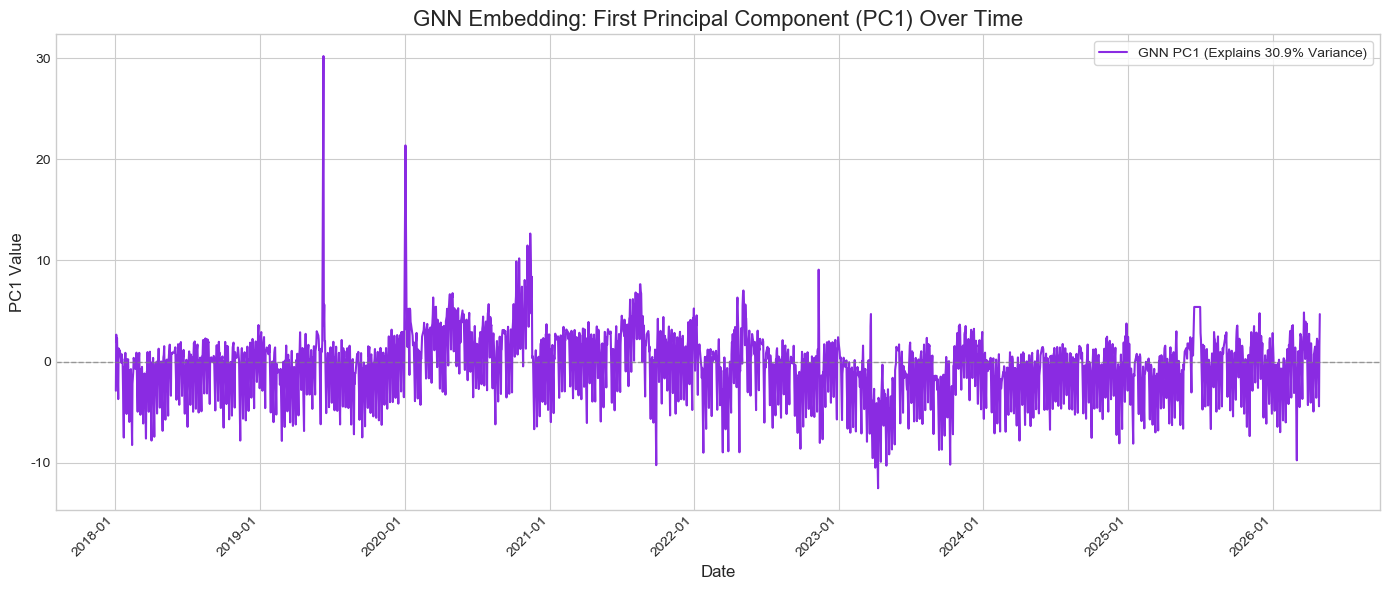

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# =========================
# 1. 參數與檔案路徑設定
# =========================
EMBEDDING_CSV = "gnn_oil_context_OOS_2018.csv"
SAVE_FIG_PATH = "results/gnn_embedding_pc1_plot.png"

# 如果你想限制畫圖的日期範圍，可以在這裡設定 (設定 None 代表畫出全部)
# START_DATE = "2020-01-01"
# END_DATE = "2026-04-28"
START_DATE = None
END_DATE = None

if not os.path.exists("results"):
    os.makedirs("results")

# =========================
# 2. 讀取資料與特徵萃取
# =========================
print(f"讀取 GNN Embedding 資料中: {EMBEDDING_CSV}")
df_emb = pd.read_csv(EMBEDDING_CSV)
df_emb['date'] = pd.to_datetime(df_emb['date'])

# 篩選日期範圍 (如果有設定的話)
if START_DATE:
    df_emb = df_emb[df_emb['date'] >= pd.Timestamp(START_DATE)]
if END_DATE:
    df_emb = df_emb[df_emb['date'] <= pd.Timestamp(END_DATE)]

df_emb.set_index('date', inplace=True)
df_emb.sort_index(inplace=True)

# 自動抓取所有名稱包含 "gnn_" 的欄位
gnn_cols = [c for c in df_emb.columns if "gnn_" in c]

if not gnn_cols:
    raise ValueError("在檔案中找不到任何 'gnn_' 開頭的欄位！請檢查檔案格式。")

print(f"找到 {len(gnn_cols)} 個 GNN 特徵欄位，準備進行 PCA 降維...")

# =========================
# 3. 標準化與 PCA 計算
# =========================
# 取出特徵矩陣
X_gnn = df_emb[gnn_cols].values

# PCA 對資料的尺度很敏感，必須先做標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_gnn)

# 計算第一主成分 (PC1)
pca = PCA(n_components=1, random_state=42)
pc1_values = pca.fit_transform(X_scaled)

# 計算 PC1 解釋了多少變異 (Explained Variance Ratio)
explained_variance = pca.explained_variance_ratio_[0] * 100
print(f"PC1 計算完成！PC1 總共解釋了 GNN 特徵 {explained_variance:.2f}% 的變異。")

# 將 PC1 加回 DataFrame 方便畫圖
df_emb['PC1'] = pc1_values

# =========================
# 4. 開始繪圖
# =========================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 顯示中文
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 顯示中文
plt.rcParams['axes.unicode_minus'] = False 

fig, ax = plt.subplots(figsize=(14, 6))

# 畫出 PC1 線圖
color_pc1 = '#8A2BE2' # 藍紫色，視覺上比較有科技感
ax.plot(df_emb.index, df_emb['PC1'], color=color_pc1, linewidth=1.5, label=f'GNN PC1 (Explains {explained_variance:.1f}% Variance)')

ax.set_title('GNN Embedding: First Principal Component (PC1) Over Time', fontsize=16, fontweight='bold')
ax.set_ylabel('PC1 Value', fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=12, fontweight='bold')

# 加入水平虛線標示 0 (基準線)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# 設定 X 軸的時間格式
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax.legend(loc='upper right', frameon=True, facecolor='white')

# 調整版面與儲存
plt.tight_layout()
plt.savefig(SAVE_FIG_PATH, dpi=300, bbox_inches='tight')
print(f"圖表已儲存至: {SAVE_FIG_PATH}")

plt.show()